# Etivity 3 Classification

## Student Name: Keith Hamilton
## Student ID: 24360627

**Task 1: Classification
Create a new Jupyter notebook named etivity3_classification.ipynb.**

In this notebook, begin by transforming the target variable. Replace the column insurance_cost with a binary column insurance_cost_binary, defined as follows:

0 if insurance_cost is less than or equal to the median insurance cost
1 otherwise
Then develop and evaluate three classification models to predict insurance_cost_binary, using:

Support Vector Machine (SVM)
Random Forest
A third classifier of your choice
Requirements:

For each classifier, build a pipeline that includes:
Data preparation
Dimensionality reduction
You may choose any algorithm for the third classifier (e.g., MLPClassifier, Naïve Bayes, k-NN, XGBoost), but you are not limited to these options.
Across your pipelines, use the following dimensionality reduction techniques:
PCA
RFE
One additional method of your choice
(Each technique should be used in at least one pipeline.)
Use GridSearchCV for hyperparameter tuning.
Evaluate and compare all models using appropriate metrics, and select the best-performing model.
Evaluate the selected model on a held-out test set.
Use permutation feature importance to assess the global importance of features for the best model.
Reflection

Include a short summary of your experience in a markdown cell (maximum 150 words).

## Importing Modules and Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score
)
from sklearn.inspection import permutation_importance
from sklearn import set_config

RANDOM_STATE = 42

## 1. Load data and initial sanity checks

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,gender,bmi,children,smoker,region,insurance_cost
0,18,male,33.770,1,no,southeast,1725.55230
1,18,male,34.100,0,no,southeast,1137.01100
2,18,female,26.315,0,no,northeast,2198.18985
3,18,female,38.665,2,no,northeast,3393.35635
4,18,female,35.625,0,no,northeast,2211.13075


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   gender          1338 non-null   object 
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   object 
 5   region          1338 non-null   object 
 6   insurance_cost  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()

,age,bmi,children,insurance_cost
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df["gender"].value_counts()

gender
male      676
female    662
Name: count, dtype: int64

In [6]:
df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [7]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

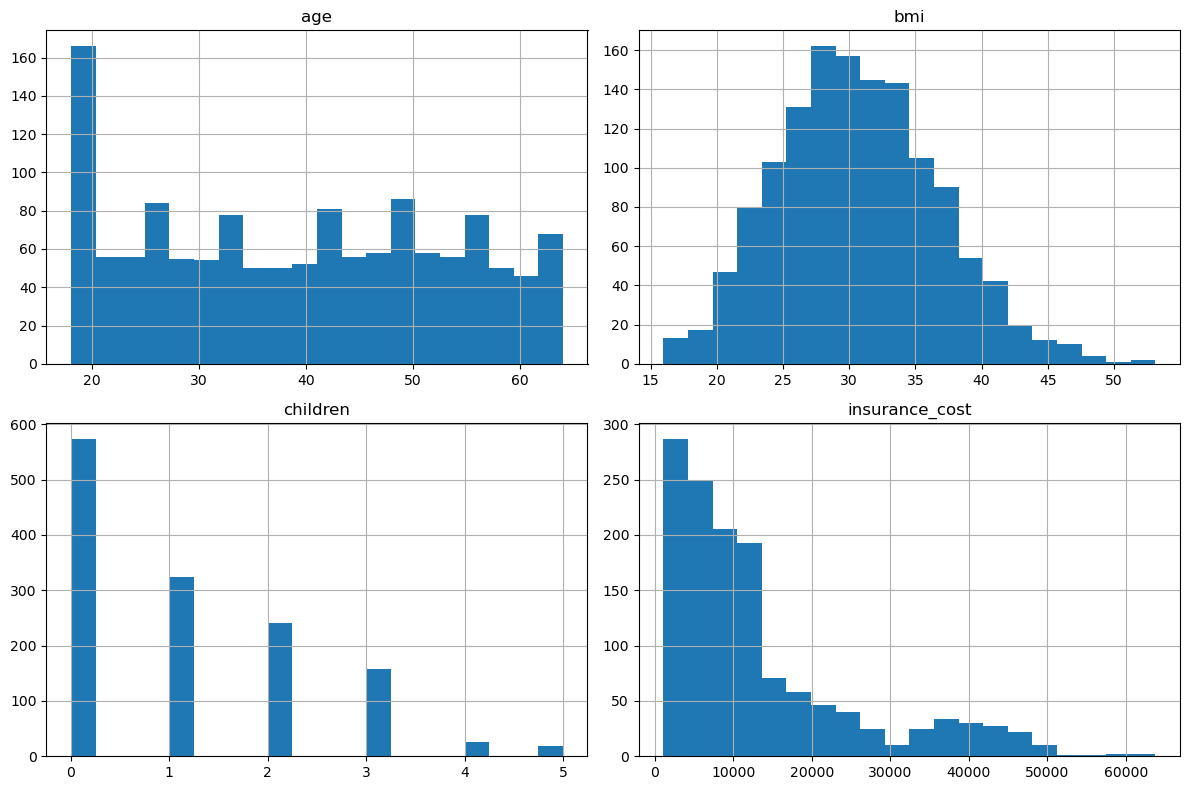

In [8]:
df[["age", "bmi", "children", "insurance_cost"]].hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()

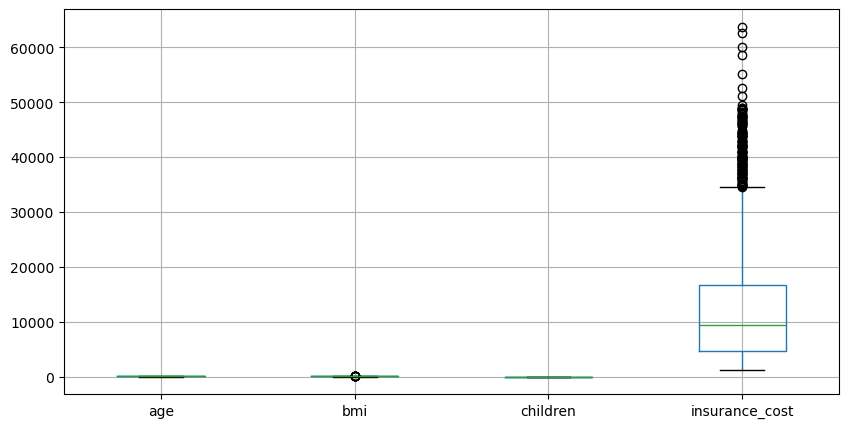

In [9]:
df.boxplot(column=["age", "bmi", "children", "insurance_cost"], figsize=(10, 5))
plt.show()

The dataset contains demographic and health-related variables used to predict medical insurance costs. It includes three numerical predictors and three categorical predictors, with `insurance_cost` as the continuous target variable. There are no missing values.

The initial checks confirm that the dataset loaded correctly, contains the expected columns, and has no obvious loading issues. These checks are used only to understand the structure of the data before modelling. More detailed exploratory analysis is carried out after the train-test split so that modelling decisions are based on the training data only.

For this classification task, the continuous target was converted into a balanced binary variable using the median insurance cost.

In [10]:
print(df.shape)
print(df.isna().sum())

(1338, 7)
age               0
gender            0
bmi               0
children          0
smoker            0
region            0
insurance_cost    0
dtype: int64


In [11]:
median_cost = df["insurance_cost"].median()
df["insurance_cost_binary"] = np.where(df["insurance_cost"] <= median_cost, 0, 1)

print("Median insurance cost:", round(median_cost, 3))
print(df["insurance_cost_binary"].value_counts())
df[["insurance_cost", "insurance_cost_binary"]].head()

Median insurance cost: 9382.033
insurance_cost_binary
0    669
1    669
Name: count, dtype: int64


,insurance_cost,insurance_cost_binary
0,1725.55230,0
1,1137.01100,0
2,2198.18985,0
3,3393.35635,0
4,2211.13075,0


The target is binarised exactly as requested:
- `0` if `insurance_cost <= median`
- `1` if `insurance_cost > median`

## 2. Define predictors, split data, and build the preprocessing pipeline

In [12]:
X = df.drop(columns=["insurance_cost", "insurance_cost_binary"])
y = df["insurance_cost_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

train_df = X_train.copy()
train_df["insurance_cost_binary"] = y_train

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1070, 6)
X_test shape: (268, 6)


## 3. Training set exploratory checks

In [13]:
train_df[["age", "bmi", "children"]].describe()

,age,bmi,children
count,1070.000000,1070.000000,1070.000000
mean,39.488785,30.863374,1.075701
std,13.992961,6.069299,1.173000
min,18.000000,15.960000,0.000000
25%,27.000000,26.600000,0.000000
50%,40.000000,30.495000,1.000000
75%,51.000000,34.848750,2.000000
max,64.000000,53.130000,5.000000


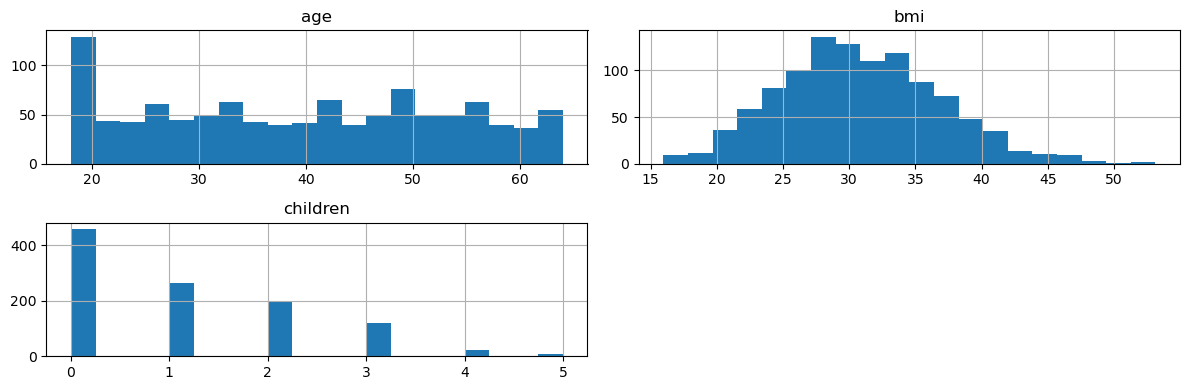

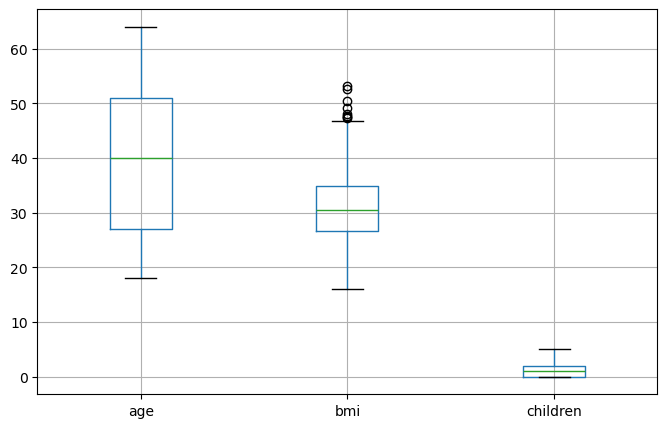

In [14]:
train_df[["age", "bmi", "children"]].hist(bins=20, figsize=(12, 4))
plt.tight_layout()
plt.show()

train_df[["age", "bmi", "children"]].boxplot(figsize=(8, 5))
plt.show()

In [15]:
for col in ["gender", "smoker", "region", "insurance_cost_binary"]:
    print(col)
    print(train_df[col].value_counts())
    print()

gender
gender
male      539
female    531
Name: count, dtype: int64

smoker
smoker
no     857
yes    213
Name: count, dtype: int64

region
region
southeast    287
northwest    266
southwest    264
northeast    253
Name: count, dtype: int64

insurance_cost_binary
insurance_cost_binary
1    535
0    535
Name: count, dtype: int64



The training set confirms that there are no missing values, the target remains balanced after stratification, and the numerical and categorical predictors have reasonable distributions. The preprocessing pipeline therefore uses median imputation for numerical variables, most-frequent imputation for categorical variables, standard scaling for numerical variables, and one-hot encoding for categorical variables. These steps are fitted inside the pipeline during cross-validation to reduce the risk of data leakage.

In [16]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["gender", "smoker", "region"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

## 4. Cross-validation setup and scoring

In [17]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1",
    "ROC_AUC": "roc_auc",
    "AP": "average_precision"
}

Each classifier is trained using a main pipeline containing preprocessing, dimensionality reduction or feature selection, and the final classifier. Following the approach from the tutorial, GridSearchCV is used to tune the classifier hyperparameters. In addition, the dimensionality reduction step is also included in the parameter grid so that PCA, RFE, SelectKBest and passthrough can be compared within the model selection process.

## 5. Pipeline 1: SVM with GridSearchCV choosing dimensionality reduction

In [18]:
N_FEATURES_OPTIONS = [5, 7, 9]

svm_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("reduce_dim", "passthrough"),
    ("clf", SVC(probability=True, random_state=RANDOM_STATE))
])

set_config(display="diagram")
svm_pipeline

,steps,"[('preprocess', ...), ('reduce_dim', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
svm_param_grid = [
    {
        "reduce_dim": [PCA()],
        "reduce_dim__n_components": N_FEATURES_OPTIONS,
        "clf__C": [1, 10],
        "clf__kernel": ["linear", "rbf"],
        "clf__gamma": ["scale", "auto"]
    },
    {
        "reduce_dim": [RFE(estimator=LogisticRegression(max_iter=2000))],
        "reduce_dim__n_features_to_select": N_FEATURES_OPTIONS,
        "clf__C": [1, 10],
        "clf__kernel": ["linear", "rbf"],
        "clf__gamma": ["scale", "auto"]
    },
    {
        "reduce_dim": [SelectKBest(score_func=f_classif)],
        "reduce_dim__k": [5, 7, 9, "all"],
        "clf__C": [1, 10],
        "clf__kernel": ["linear", "rbf"],
        "clf__gamma": ["scale", "auto"]
    },
    {
        "reduce_dim": ["passthrough"],
        "clf__C": [1, 10],
        "clf__kernel": ["linear", "rbf"],
        "clf__gamma": ["scale", "auto"]
    }
]

svm_search = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=cv,
    scoring=scoring,
    refit="F1",
    n_jobs=-1,
    return_train_score=False
)

svm_search.fit(X_train, y_train)

print("Best SVM CV F1:", round(svm_search.best_score_, 3))
print("Best SVM parameters:", svm_search.best_params_)

Best SVM CV F1: 0.937
Best SVM parameters: {'clf__C': 10, 'clf__gamma': 'auto', 'clf__kernel': 'rbf', 'reduce_dim': SelectKBest(), 'reduce_dim__k': 7}


The SVM model was tuned over the regularisation parameter $C$, kernel type (linear and RBF), and kernel coefficient $\gamma$, which together control the model complexity and the flexibility of the decision boundary.

## 6. Pipeline 2: Random Forest with GridSearchCV choosing dimensionality reduction

In [20]:
rf_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("reduce_dim", "passthrough"),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE))
])

rf_pipeline

,steps,"[('preprocess', ...), ('reduce_dim', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
rf_param_grid = [
    {
        "reduce_dim": [PCA()],
        "reduce_dim__n_components": N_FEATURES_OPTIONS,
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [5, 10],
        "clf__min_samples_split": [2, 5]
    },
    {
        "reduce_dim": [RFE(estimator=LogisticRegression(max_iter=2000))],
        "reduce_dim__n_features_to_select": N_FEATURES_OPTIONS,
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [5, 10],
        "clf__min_samples_split": [2, 5]
    },
    {
        "reduce_dim": [SelectKBest(score_func=f_classif)],
        "reduce_dim__k": [5, 7, 9, "all"],
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [5, 10],
        "clf__min_samples_split": [2, 5]
    },
    {
        "reduce_dim": ["passthrough"],
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [5, 10],
        "clf__min_samples_split": [2, 5]
    }
]

rf_search = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=cv,
    scoring=scoring,
    refit="F1",
    n_jobs=-1,
    return_train_score=False
)

rf_search.fit(X_train, y_train)

print("Best Random Forest CV F1:", round(rf_search.best_score_, 3))
print("Best Random Forest parameters:", rf_search.best_params_)

Best Random Forest CV F1: 0.937
Best Random Forest parameters: {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 100, 'reduce_dim': SelectKBest(), 'reduce_dim__k': 9}


## 7. Pipeline 3: kNN with GridSearchCV choosing dimensionality reduction

In [22]:
knn_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("reduce_dim", "passthrough"),
    ("clf", KNeighborsClassifier())
])

knn_pipeline

,steps,"[('preprocess', ...), ('reduce_dim', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [23]:
knn_param_grid = [
    {
        "reduce_dim": [PCA()],
        "reduce_dim__n_components": N_FEATURES_OPTIONS,
        "clf__n_neighbors": [5, 7, 9],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2]
    },
    {
        "reduce_dim": [RFE(estimator=LogisticRegression(max_iter=2000))],
        "reduce_dim__n_features_to_select": N_FEATURES_OPTIONS,
        "clf__n_neighbors": [5, 7, 9],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2]
    },
    {
        "reduce_dim": [SelectKBest(score_func=f_classif)],
        "reduce_dim__k": [5, 7, 9, "all"],
        "clf__n_neighbors": [5, 7, 9],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2]
    },
    {
        "reduce_dim": ["passthrough"],
        "clf__n_neighbors": [5, 7, 9],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2]
    }
]

knn_search = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    cv=cv,
    scoring=scoring,
    refit="F1",
    n_jobs=-1,
    return_train_score=False
)

knn_search.fit(X_train, y_train)

print("Best kNN CV F1:", round(knn_search.best_score_, 3))
print("Best kNN parameters:", knn_search.best_params_)

Best kNN CV F1: 0.92
Best kNN parameters: {'clf__n_neighbors': 9, 'clf__p': 1, 'clf__weights': 'distance', 'reduce_dim': RFE(estimator=LogisticRegression(max_iter=2000)), 'reduce_dim__n_features_to_select': 9}


## 8. Compare cross-validation performance

In [24]:
searches = {
    "SVM": svm_search,
    "Random Forest": rf_search,
    "kNN": knn_search
}

cv_results = {}

for model_name, search in searches.items():
    best_idx = search.best_index_
    result = search.cv_results_
    cv_results[model_name] = {}
    for metric_name in scoring.keys():
        fold_scores = []
        for i in range(cv.n_splits):
            fold_scores.append(result[f"split{i}_test_{metric_name}"][best_idx])
        cv_results[model_name][metric_name] = np.array(fold_scores)

summary_rows = []
for model_name, metrics_dict in cv_results.items():
    row = {"Model": model_name}
    for metric_name, values in metrics_dict.items():
        row[f"{metric_name}_mean"] = np.mean(values)
        row[f"{metric_name}_std"] = np.std(values)
    summary_rows.append(row)

cv_summary = pd.DataFrame(summary_rows).sort_values("F1_mean", ascending=False)
cv_summary.round(3)

,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,ROC_AUC_mean,ROC_AUC_std,AP_mean,AP_std
0,SVM,0.940,0.022,0.976,0.017,0.903,0.043,0.937,0.024,0.959,0.028,0.973,0.017
1,Random Forest,0.940,0.023,0.976,0.019,0.903,0.045,0.937,0.025,0.953,0.029,0.971,0.017
2,kNN,0.922,0.023,0.947,0.034,0.897,0.049,0.920,0.024,0.941,0.023,0.953,0.017


Across all three classifiers, SelectKBest was selected more frequently than PCA or RFE in the optimal configurations. This suggests that selecting the most informative features directly was more effective than projecting the data into a lower dimensional space. PCA did not consistently improve performance, likely because interpretability is reduced and the dataset already has a relatively small number of features.

The models were compared using 10-fold stratified cross-validation on the training data. F1 score was used as the main selection metric because the task is binary classification and F1 balances precision and recall. Accuracy, precision, recall, ROC AUC and average precision were also reviewed to provide a broader comparison of model performance.


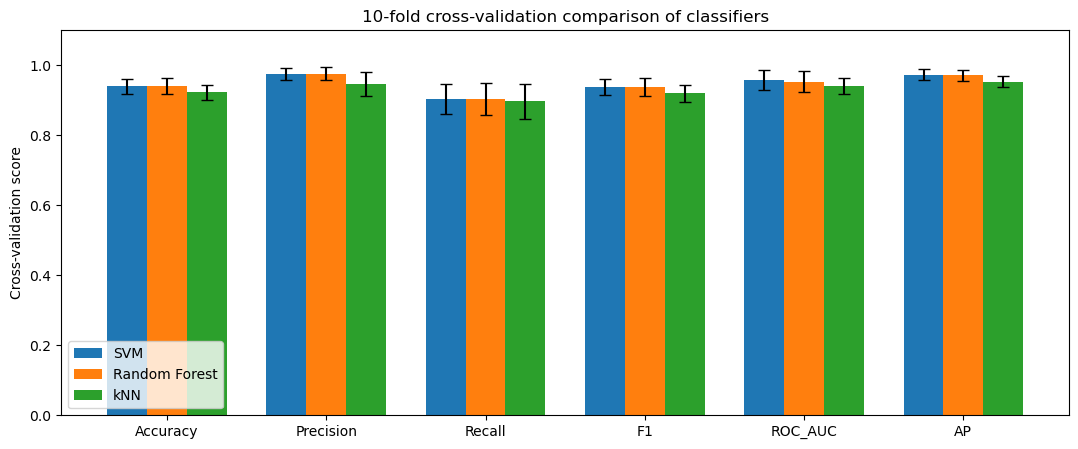

In [25]:
metric_names = list(scoring.keys())
labels = list(cv_results.keys())
x = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))

for offset, label in zip([-width, 0, width], labels):
    means = [np.mean(cv_results[label][m]) for m in metric_names]
    stds = [np.std(cv_results[label][m]) for m in metric_names]
    ax.bar(x + offset, means, width, yerr=stds, capsize=4, label=label)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Cross-validation score")
ax.set_title("10-fold cross-validation comparison of classifiers")
ax.legend()
plt.show()

## 9. Choose the best classifier from cross-validation

In [26]:
best_name = max(searches, key=lambda name: searches[name].best_score_)
best_model = searches[best_name].best_estimator_
best_cv_f1 = searches[best_name].best_score_

print("Chosen model:", best_name)
print("Best mean CV F1:", round(best_cv_f1, 3))

Chosen model: SVM
Best mean CV F1: 0.937


SVM was selected as the final model because it achieved the highest mean cross-validation F1 score. Cross-validation performance is prioritised over test set performance for model selection, as it provides a more reliable estimate of generalisation across multiple data splits.

## 10. Final hold-out test set comparison

In [27]:
def evaluate_classifier(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    fpr, tpr, _ = roc_curve(y_eval, y_proba)
    precision_curve, recall_curve, _ = precision_recall_curve(y_eval, y_proba)

    return {
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "roc_auc": auc(fpr, tpr),
        "ap": average_precision_score(y_eval, y_proba),
        "confusion_matrix": confusion_matrix(y_eval, y_pred),
        "fpr": fpr,
        "tpr": tpr,
        "precision_curve": precision_curve,
        "recall_curve": recall_curve
    }

test_results = {
    model_name: evaluate_classifier(search.best_estimator_, X_test, y_test)
    for model_name, search in searches.items()
}

test_summary = pd.DataFrame([
    {
        "Model": model_name,
        "Accuracy": result["accuracy"],
        "Precision": result["precision"],
        "Recall": result["recall"],
        "F1": result["f1"],
        "ROC_AUC": result["roc_auc"],
        "AP": result["ap"]
    }
    for model_name, result in test_results.items()
]).sort_values("F1", ascending=False)

test_summary.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,AP
1,Random Forest,0.914,0.966,0.858,0.909,0.927,0.954
0,SVM,0.907,0.958,0.851,0.901,0.940,0.959
2,kNN,0.903,0.950,0.851,0.898,0.917,0.946


As a final check on the held-out test set, Random Forest achieved the highest F1 score, but the difference compared with SVM is small. The selected final model remains SVM because model selection was based on the best mean cross-validation F1 score on the training data.

The hold-out test set was used only at the end to estimate generalisation performance. Therefore, the test results are reported as a final evaluation step rather than being used to reselect the model.

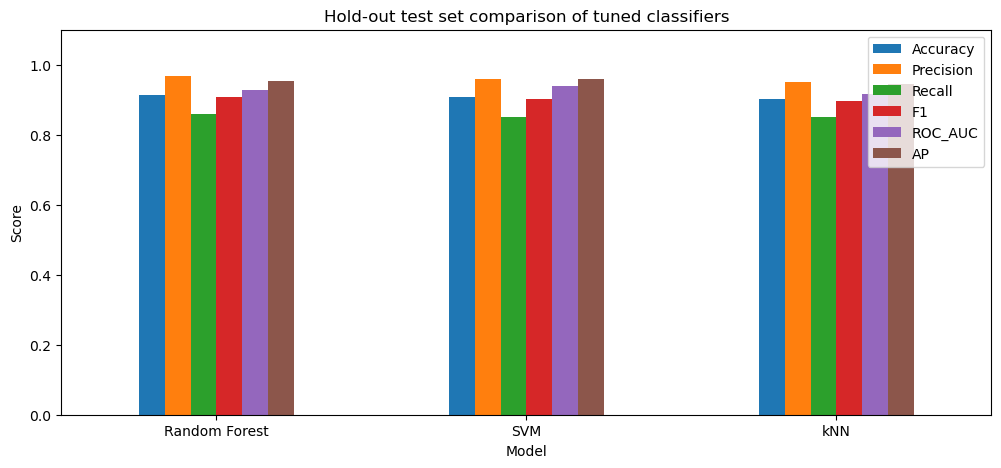

In [28]:
test_plot_df = test_summary.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "AP"]]
test_plot_df.plot.bar(rot=0, figsize=(12, 5))
plt.ylim(0, 1.1)
plt.title("Hold-out test set comparison of tuned classifiers")
plt.ylabel("Score")
plt.show()

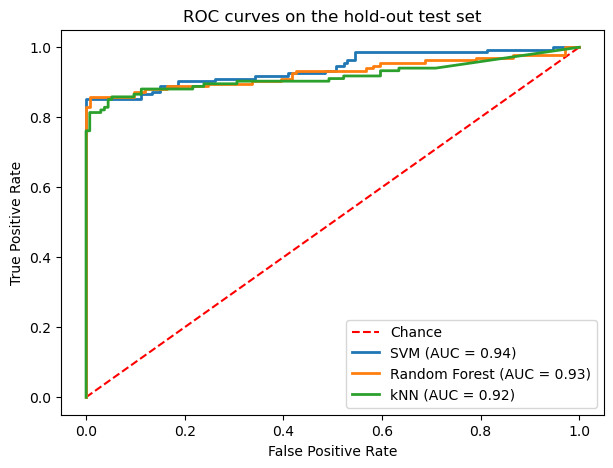

In [29]:
plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Chance")

for model_name, result in test_results.items():
    plt.plot(result["fpr"], result["tpr"], lw=2, label=f"{model_name} (AUC = {result['roc_auc']:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves on the hold-out test set")
plt.legend(loc="lower right")
plt.show()

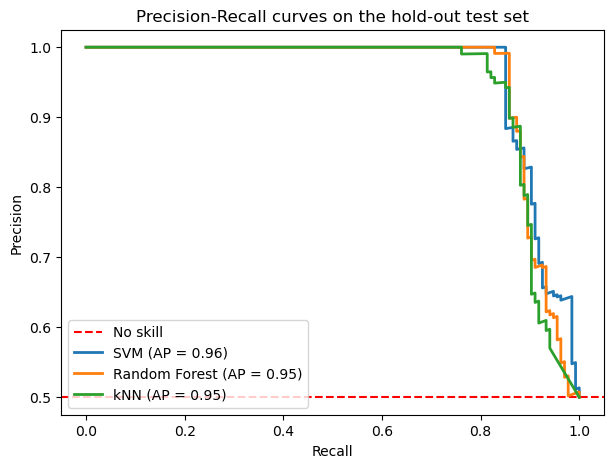

In [30]:
plt.figure(figsize=(7, 5))
plt.axhline(y=y_test.mean(), color="red", linestyle="--", label="No skill")

for model_name, result in test_results.items():
    plt.plot(result["recall_curve"], result["precision_curve"], lw=2, label=f"{model_name} (AP = {result['ap']:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves on the hold-out test set")
plt.legend(loc="lower left")
plt.show()

## 11. Evaluate the chosen final classifier in more detail

In [31]:
best_test_result = test_results[best_name]
cm = pd.DataFrame(
    best_test_result["confusion_matrix"],
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("Chosen classifier:", best_name)
display(cm)
print("Accuracy:", round(best_test_result["accuracy"], 3))
print("Precision:", round(best_test_result["precision"], 3))
print("Recall:", round(best_test_result["recall"], 3))
print("F1:", round(best_test_result["f1"], 3))
print("ROC AUC:", round(best_test_result["roc_auc"], 3))
print("Average Precision:", round(best_test_result["ap"], 3))

Chosen classifier: SVM


,Predicted 0,Predicted 1
Actual 0,129,5
Actual 1,20,114


Accuracy: 0.907
Precision: 0.958
Recall: 0.851
F1: 0.901
ROC AUC: 0.94
Average Precision: 0.959


## 12. Feature importance for the chosen classifier

In [32]:
permutation = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": permutation.importances_mean,
    "Importance Std": permutation.importances_std
}).sort_values("Importance Mean", ascending=False)

importance_df

,Feature,Importance Mean,Importance Std
0,age,0.262373,0.026155
4,smoker,0.232458,0.026327
5,region,0.005095,0.006670
3,children,0.004480,0.009856
1,gender,-0.001063,0.007382
2,bmi,-0.008624,0.006141


The negative importance values suggest that permuting those features did not reduce the model's F1 score on this test split, so they appear less useful for the selected model compared with age and smoker status.

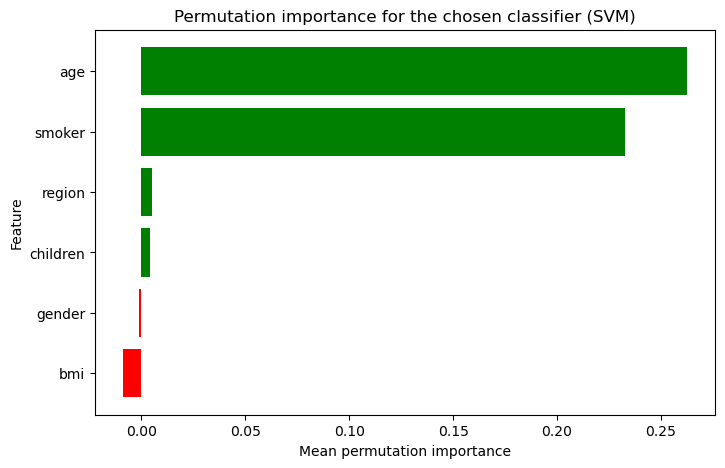

In [33]:
top_importance = importance_df.head(10)

plt.figure(figsize=(8, 5))

colors = ["green" if val > 0 else "red" for val in top_importance["Importance Mean"]]

plt.barh(top_importance["Feature"], top_importance["Importance Mean"], color=colors)

plt.xlabel("Mean permutation importance")
plt.ylabel("Feature")
plt.title(f"Permutation importance for the chosen classifier ({best_name})")
plt.gca().invert_yaxis()

plt.show()

Permutation feature importance was applied to the final selected classification pipeline using the original test features. Negative importance values can occur when shuffling a feature slightly improves performance on this test split. This suggests that the feature may be adding noise or may not be useful for the selected model. In this classification task, age and smoker status appear most important, while BMI is less important for predicting whether insurance cost is above or below the median.


## 13. Reflection (≤150 words)

This task compared three classification pipelines for predicting whether insurance cost is above the median. I used SVM, Random Forest and kNN, with preprocessing and dimensionality reduction included inside each pipeline to reduce the risk of data leakage. GridSearchCV was used to tune model hyperparameters and compare PCA, RFE, SelectKBest and passthrough as dimensionality reduction or feature selection options. The models were compared using F1 as the main cross-validation metric, while accuracy, precision, recall, ROC AUC and average precision were also reviewed. SVM achieved the best mean cross-validation F1 score and was evaluated once on the held-out test set. Permutation feature importance showed that age and smoker status were the most influential original features.